In [38]:
import pandas as pd
import numpy as np

print("Jupyter is working!")

Jupyter is working!


In [76]:
import re
import json
import importlib
import utils
importlib.reload(utils)

<module 'utils' from '/Users/lovedeep/work/git/ai-engineering/andrewng-course-agenticai/course-modules/Reflection-Design-Pattern/utils.py'>

In [40]:
df = utils.load_and_prepare_data('coffee_sales.csv')

In [41]:
utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data", border=1)

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-03-05,17:21,card,ANON-0000-0000-0028,3.870,Hot Chocolate,1,3,2024
2025-03-14,17:01,card,ANON-0000-0000-1291,2.596,Americano,1,3,2025
2024-10-08,17:02,card,ANON-0000-0000-0731,3.576,Cappuccino,4,10,2024
2025-02-12,08:14,card,ANON-0000-0000-1163,3.576,Cocoa,1,2,2025
2024-07-03,07:19,card,ANON-0000-0000-0343,3.772,Cappuccino,3,7,2024


In [52]:
print(df.columns)

Index(['date', 'time', 'cash_type', 'card', 'price', 'coffee_name', 'quarter',
       'month', 'year'],
      dtype='str')


In [42]:
import matplotlib
from openai import OpenAI
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

In [43]:
load_dotenv()

True

In [53]:
def generate_chart_code(question: str, model: str, output_path_v1: str) -> str:
    prompt = f"""
    You are a Python data analyst.

    Dataset schema:
    {schema}

    User question:
    {question}

    Rules:
    - Use pandas and matplotlib only.
    - Read data from coffee_sales.csv.
    - Return only Python code inside <execute_python> and </execute_python> tags.
    - Save the output chart as '{output_path_v1}'
    - Do not explain anything.
    - Do not create the dataframe again, we already have that ready as df
    """
    llm = ChatOpenAI(
        model=model,
        temperature=1
    )
    response = llm.invoke(prompt)
    return response.content
    


In [73]:
schema = """
coffee_sales.csv columns:
- date: sale date
- time: sale time
- cash_type: cash or card
- card: anonymized card id
- price: sale amount / revenue
- coffee_name: coffee product name
- quarter: quarter number
- month: month number
- year: year
"""

In [55]:
question = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv."

In [56]:
code_v1 = generate_chart_code(
    model="gpt-4.1-mini",
    question="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    output_path_v1="chart_v1.png"
)

In [57]:
print(code_v1)

<execute_python>
import matplotlib.pyplot as plt

# Filter data for Q1 in 2024 and 2025
df_q1 = df[(df['quarter'] == 1) & (df['year'].isin([2024, 2025]))]

# Aggregate sales by year and month
sales_agg = df_q1.groupby(['year', 'month'])['price'].sum().unstack(level=0)

# Plotting
sales_agg.plot(kind='bar')
plt.title('Q1 Coffee Sales Comparison: 2024 vs 2025')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('chart_v1.png')
plt.close()
</execute_python>


In [58]:
utils.print_code_html(code_v1, title="LLM outputting the code")


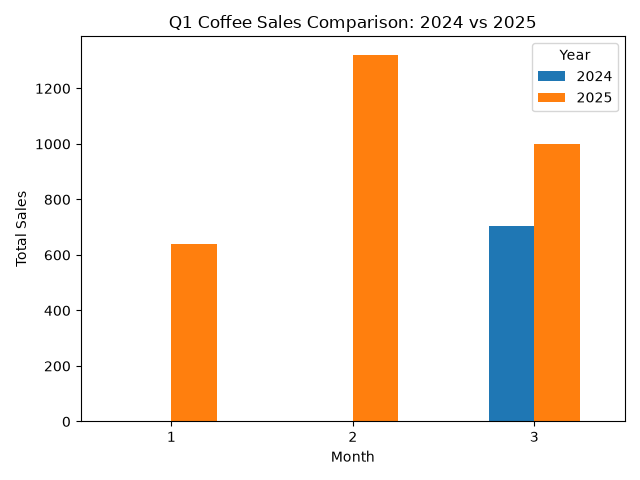

In [66]:
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_code_html(initial_code, title="Extracted Code to Execute")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)

In [69]:
from langchain_core.messages import HumanMessage

In [81]:
def reflect_on_image_and_regenerate( chart_path: str, schema: str, instruction: str, model: str, output_path_v2: str, code_v1: str):
    """
    The goal here is to simulate how a human would review a first draft of a chart—looking for strengths, weaknesses, and areas for improvement.
    Here’s what happens:
    1. Provide the chart to the LLM: The generated chart (chart_v1.png) is shared with the LLM so it can “see” the visualization.
    2. Analyze the chart visually: The LLM reviews elements like clarity, labeling, accuracy, and overall readability.
    3. Generate feedback: The LLM suggests improvements—for example, fixing axis labels, adjusting the chart type, improving color choices, or highlighting missing legends.
    """

    media_type, b64 = utils.encode_image_b64(chart_path)

    prompt = f"""
    You are a Python data analyst.
    Your task: I will share you a chart png file and python code which generated that chart.
    Visualize the chart & code, further analyze it from clarity, labeling, accuracy and overall readability perspective. 
    Then gather your feedback and re-create a new code python code for me inside <execute_python> tags.

    Dataset schema:
    {schema}

    User instructions:
    {instruction}

    code:
    {code_v1}

    chart:
    {chart_path}

    Rules:
    - Use pandas and matplotlib only.
    - Return Python code inside <execute_python> and </execute_python> tags.
    - Save the output chart as '{output_path_v2}'
    - Do not explain anything and I expect 2 things from you and nothing i.e. feedback and python code
    - Do not create the dataframe again, we already have that ready as df
    - datetime is already datetime object

    <feedback>
    Your concise feedback here.
    </feedback>

    <execute_python>
    Python code here.
    </execute_python>
    
    """
    llm = ChatOpenAI(
        model=model,
        temperature=1
    )
    message = HumanMessage(
        content=[
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:{media_type};base64,{b64}"
                }
            }
        ]
    )
    response = llm.invoke([message])
    content = response.content

    feedback_match = re.search(
        r"<feedback>(.*?)</feedback>",
        content,
        re.DOTALL
    )

    code_match = re.search(
        r"<execute_python>(.*?)</execute_python>",
        content,
        re.DOTALL
    )

    feedback = feedback_match.group(1).strip() if feedback_match else ""
    code_v2 = code_match.group(1).strip() if code_match else ""
    return feedback, code_v2

In [82]:
feedback, code_v2 = reflect_on_image_and_regenerate(
    model="gpt-4.1-mini",
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    chart_path="chart_v1.png",
    output_path_v2="chart_v2.png",
    code_v1=code_v1,
    schema=schema
)

In [83]:
utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")